In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              BaggingRegressor, BaggingClassifier,
                              AdaBoostRegressor, AdaBoostClassifier)
from xgboost import XGBRegressor, XGBClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import mutual_info_regression, SelectKBest

# Metrics
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score, precision_score, recall_score)

# Neural Networks
from sklearn.neural_network import MLPRegressor, MLPClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Image processing
from skimage import filters, feature

# Nastavitve
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
np.random.seed(1234)
tf.random.set_seed(1234)

print("✅ Vse knjižnice uspešno naložene!")


✅ Vse knjižnice uspešno naložene!


In [3]:
print("="*70)
print("NALAGANJE PODATKOV - REGRESIJA (Bike Data)")
print("="*70)

# Nalaganje
df_bike = pd.read_csv('bike_data.csv')

print(f"Oblika podatkovne zbirke: {df_bike.shape}")
print(f"\nPrvih 5 vrstic:")
print(df_bike.head())
print(f"\nManjkajoče vrednosti:")
print(df_bike.isnull().sum())


NALAGANJE PODATKOV - REGRESIJA (Bike Data)
Oblika podatkovne zbirke: (8760, 14)

Prvih 5 vrstic:
         date  rented_bike_count  hour  temperature  humidity  wind_speed  \
0  01/12/2017                254     0         -5.2        37         2.2   
1  01/12/2017                204     1         -5.5        38         0.8   
2  01/12/2017                173     2         -6.0        39         1.0   
3  01/12/2017                107     3         -6.2        40         0.9   
4  01/12/2017                 78     4         -6.0        36         2.3   

   visibility  dew_point_temperature  solar_radiation  rainfall  snowfall  \
0        2000                  -17.6              0.0       0.0       0.0   
1        2000                  -17.6              0.0       0.0       0.0   
2        2000                  -17.7              0.0       0.0       0.0   
3        2000                  -17.6              0.0       0.0       0.0   
4        2000                  -18.6              0.0  

In [4]:
# Pretvorba datuma
df_bike[['day', 'month', 'year']] = df_bike['date'].str.split('/', expand=True)
df_bike['day'] = df_bike['day'].astype(int)
df_bike['month'] = df_bike['month'].astype(int)
df_bike['year'] = df_bike['year'].astype(int)
df_bike.drop('date', axis=1, inplace=True)

# Identifikacija numeričnih in kategoričnih stolpcev
numeric_cols = df_bike.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('rented_bike_count')  # Target odstranimo

categorical_cols = ['seasons', 'holiday', 'work_hours']

print(f"Numerične značilke: {numeric_cols}")
print(f"Kategorične značilke: {categorical_cols}")


Numerične značilke: ['hour', 'temperature', 'humidity', 'wind_speed', 'visibility', 'dew_point_temperature', 'solar_radiation', 'rainfall', 'snowfall', 'day', 'month', 'year']
Kategorične značilke: ['seasons', 'holiday', 'work_hours']


In [5]:
print("="*70)
print("ZAPOLNJEVANJE MANJKAJOČIH VREDNOSTI - Linearna regresija")
print("="*70)

df_bike_filled = df_bike.copy()

for col in numeric_cols:
    if df_bike_filled[col].isnull().sum() > 0:
        print(f"\n🔧 Zapolnjujem stolpec: {col}")
        print(f"   Manjkajočih vrednosti: {df_bike_filled[col].isnull().sum()}")

        # Ločimo podatke z in brez manjkajočih vrednosti
        train_data = df_bike_filled[df_bike_filled[col].notnull()]
        test_data = df_bike_filled[df_bike_filled[col].isnull()]

        if len(test_data) > 0:
            # Priprava značilk
            other_numeric = [c for c in numeric_cols if c != col and df_bike_filled[c].notnull().all()]

            if len(other_numeric) > 0:
                X_train = train_data[other_numeric] #vhodni podatki
                y_train = train_data[col] #ciljne vrednosti
                X_test = test_data[other_numeric] # podatki za napoved

                # Linearna regresija
                lr_model = LinearRegression()
                lr_model.fit(X_train, y_train)
                predictions = lr_model.predict(X_test)

                # Zapolnimo vrednosti
                df_bike_filled.loc[df_bike_filled[col].isnull(), col] = predictions
                print(f"   ✅ Zapolnjeno z linearno regresijo")
            else:
                # Fallback na povprečje
                df_bike_filled[col].fillna(df_bike_filled[col].mean(), inplace=True)
                print(f"   ⚠️  Zapolnjeno s povprečjem (ni dovolj značilk)")

print("\n✅ Manjkajoče vrednosti zapolnjene!")
print(f"Preostale manjkajoče vrednosti: {df_bike_filled.isnull().sum().sum()}")


ZAPOLNJEVANJE MANJKAJOČIH VREDNOSTI - Linearna regresija

🔧 Zapolnjujem stolpec: dew_point_temperature
   Manjkajočih vrednosti: 86
   ✅ Zapolnjeno z linearno regresijo

✅ Manjkajoče vrednosti zapolnjene!
Preostale manjkajoče vrednosti: 0


ANALIZA PORAZDELITEV NUMERIČNIH ZNAČILK


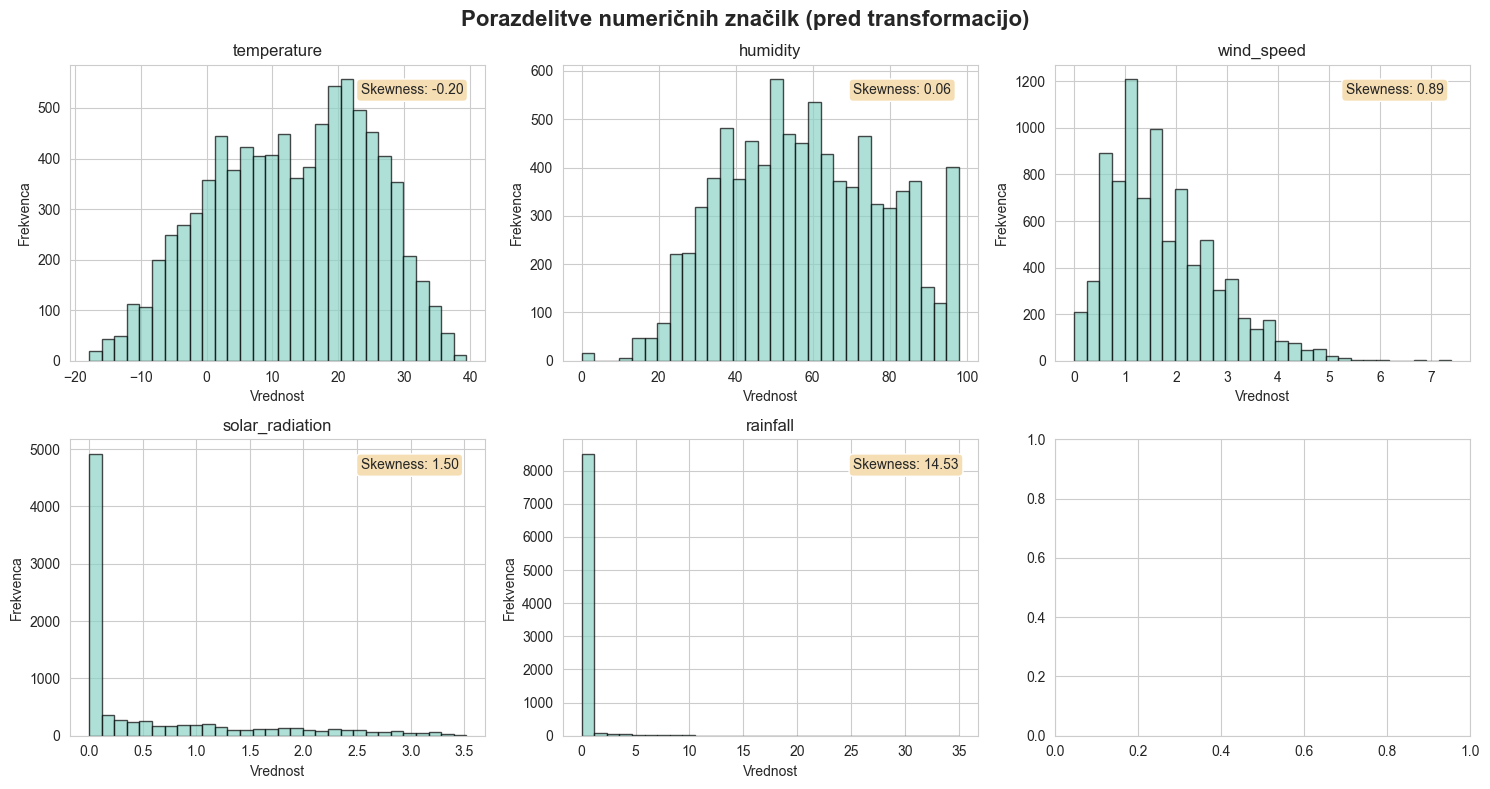


📊 Interpretacija:
• Skewness > 1: Desno asimetrična → uporabi Log/Box-Cox
• Skewness < -1: Levo asimetrična → uporabi eksponentno transformacijo
• -1 < Skewness < 1: Približno normalna → standardizacija


In [6]:
print("="*70)
print("ANALIZA PORAZDELITEV NUMERIČNIH ZNAČILK")
print("="*70)

# Izberemo nekaj ključnih značilk za analizo
key_features = ['temperature', 'humidity', 'wind_speed', 'solar_radiation', 'rainfall']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Porazdelitve numeričnih značilk (pred transformacijo)', fontsize=16, fontweight='bold')

for idx, col in enumerate(key_features):
    if idx < 6:
        ax = axes[idx // 3, idx % 3]
        df_bike_filled[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
        ax.set_title(col)
        ax.set_xlabel('Vrednost')
        ax.set_ylabel('Frekvenca')

        # Dodaj statistiko
        skewness = df_bike_filled[col].skew()
        ax.text(0.7, 0.9, f'Skewness: {skewness:.2f}',
                transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='wheat'))

plt.tight_layout()
plt.show()

print("\n📊 Interpretacija:")
print("• Skewness > 1: Desno asimetrična → uporabi Log/Box-Cox")
print("• Skewness < -1: Levo asimetrična → uporabi eksponentno transformacijo")
print("• -1 < Skewness < 1: Približno normalna → standardizacija")


TRANSFORMACIJA NUMERIČNIH ZNAČILK (glede na skewness)
✅ Normalne porazdelitve (samo standardizacija): ['temperature', 'humidity', 'wind_speed']
✅ Power Transform: solar_radiation (skewness: 0.56)
✅ Power Transform: visibility (skewness: -0.52)
✅ Power Transform: dew_point_temperature (skewness: -0.12)
✅ Log1p Transform: rainfall (skewness: 6.46)
✅ Log1p Transform: snowfall (skewness: 5.81)

✅ Transformacije končane!


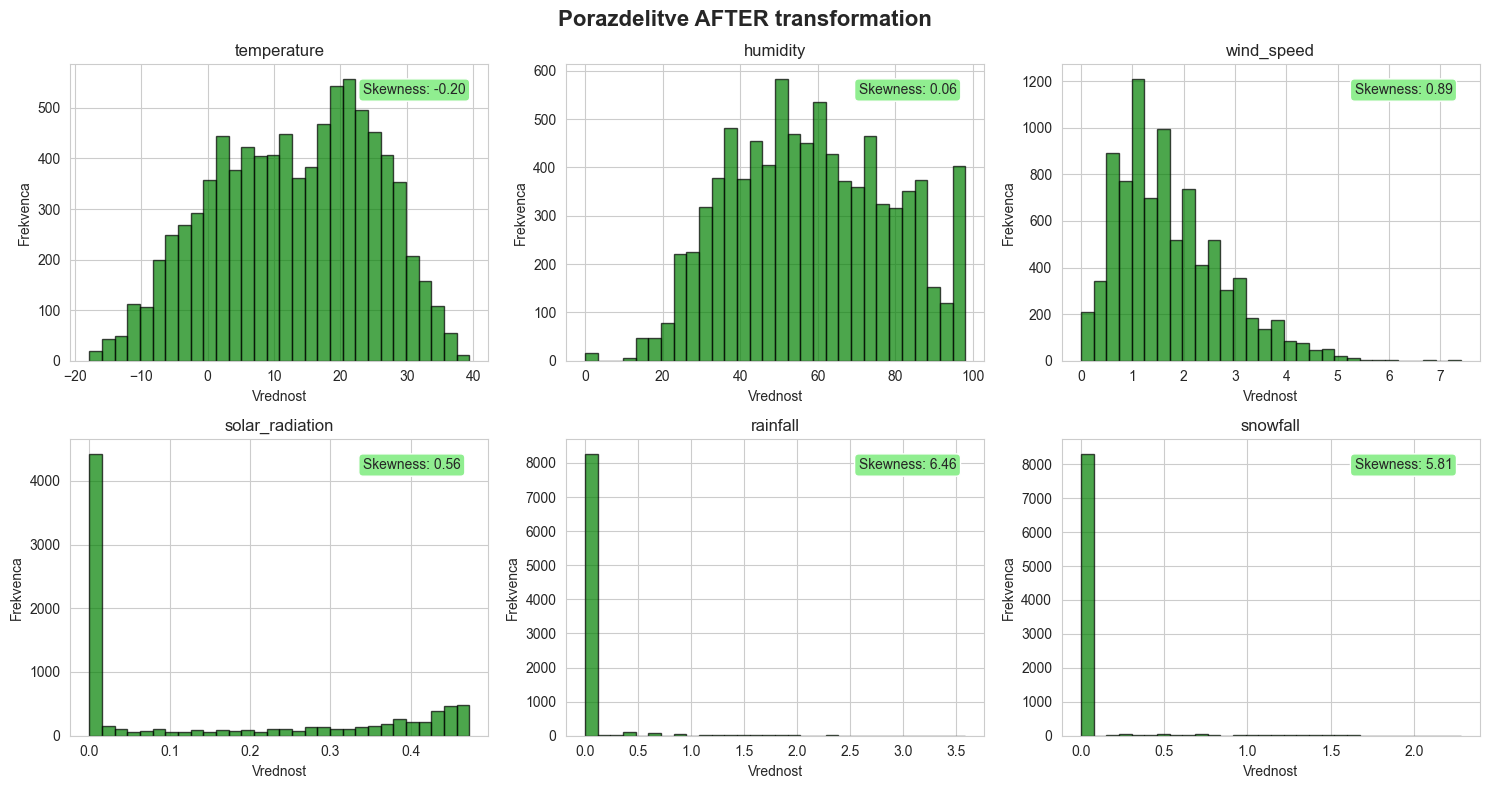

In [7]:
print("="*70)
print("TRANSFORMACIJA NUMERIČNIH ZNAČILK (glede na skewness)")
print("="*70)

df_bike_transformed = df_bike_filled.copy()

# 1. NORMALNE PORAZDELITVE (-1 < Skewness < 1) → samo standardizacija kasneje
normal_cols = ['temperature', 'humidity', 'wind_speed']
print(f"✅ Normalne porazdelitve (samo standardizacija): {normal_cols}")

# 2. ZMERNA ASIMETRIJA (1 < Skewness < 3) → Power Transform
moderate_skew_cols = ['solar_radiation', 'visibility', 'dew_point_temperature']

transformer = PowerTransformer(method='yeo-johnson', standardize=False)
for col in moderate_skew_cols:
    if col in df_bike_transformed.columns:
        df_bike_transformed[col] = transformer.fit_transform(df_bike_transformed[[col]])
        new_skew = df_bike_transformed[col].skew()
        print(f"✅ Power Transform: {col} (skewness: {new_skew:.2f})")

# 3. EKSTREMNA ASIMETRIJA (Skewness > 3) → Log1p
extreme_skew_cols = ['rainfall', 'snowfall']
for col in extreme_skew_cols:
    if col in df_bike_transformed.columns:
        df_bike_transformed[col] = np.log1p(df_bike_transformed[col])
        new_skew = df_bike_transformed[col].skew()
        print(f"✅ Log1p Transform: {col} (skewness: {new_skew:.2f})")

print("\n✅ Transformacije končane!")

# Vizualizacija PO transformaciji
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Porazdelitve AFTER transformation', fontsize=16, fontweight='bold')

key_features = ['temperature', 'humidity', 'wind_speed', 'solar_radiation', 'rainfall', 'snowfall']

for idx, col in enumerate(key_features):
    if idx < 6 and col in df_bike_transformed.columns:
        ax = axes[idx // 3, idx % 3]
        df_bike_transformed[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7, color='green')
        ax.set_title(col)
        ax.set_xlabel('Vrednost')
        ax.set_ylabel('Frekvenca')

        skewness = df_bike_transformed[col].skew()
        ax.text(0.7, 0.9, f'Skewness: {skewness:.2f}',
                transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='lightgreen'))

plt.tight_layout()
plt.show()


In [8]:
print("="*70)
print("IZGRADNJA NOVIH ZNAČILK (Feature Engineering)")
print("="*70)

# OBVEZNI DEL - 3 nove značilke

# 1. Toplotni indeks (Heat Index) - kombinacija temperature in vlažnosti
df_bike_transformed['heat_index'] = (df_bike_transformed['temperature'] +
                                     df_bike_transformed['humidity'] * 0.5)
print("✅ 1. Heat Index (temperatura + vlažnost)")

# 2. Weather Score - kombinacija več vremenskih parametrov
df_bike_transformed['weather_score'] = (
    df_bike_transformed['temperature'] * 0.4 +
    (100 - df_bike_transformed['humidity']) * 0.3 +
    df_bike_transformed['visibility'] * 0.2 +
    df_bike_transformed['solar_radiation'] * 0.1
)
print("✅ 2. Weather Score (kompozitna ocena vremena)")

# 3. Is_Weekend - ali je vikend?
df_bike_transformed['is_weekend'] = df_bike_transformed['day'].apply(
    lambda x: 1 if x % 7 in [0, 6] else 0  # Poenostavljena logika
)
print("✅ 3. Is Weekend (binarna značilka)")

# DODATNI DEL - 2 dodatni značilki

# 4. Rush Hour - ali je prometna konica?
df_bike_transformed['rush_hour'] = df_bike_transformed['hour'].apply(
    lambda x: 1 if x in [7, 8, 9, 17, 18, 19] else 0
)
print("✅ 4. Rush Hour (prometna konica)")

# 5. Season_Temp_Interaction - interakcija med sezono in temperaturo
# Najprej moramo one-hot encodati seasons
df_temp_seasons = pd.get_dummies(df_bike_transformed['seasons'], prefix='season')
df_bike_transformed = pd.concat([df_bike_transformed, df_temp_seasons], axis=1)

# Potem naredimo interakcijo
for season_col in df_temp_seasons.columns:
    df_bike_transformed[f'{season_col}_temp'] = (
        df_bike_transformed[season_col] * df_bike_transformed['temperature']
    )

print("✅ 5. Season-Temperature Interaction (interakcija sezona-temperatura)")

print(f"\n📊 Skupno število značilk: {df_bike_transformed.shape[1]}")
print(f"Nove značilke: heat_index, weather_score, is_weekend, rush_hour, season_temp_interactions")


IZGRADNJA NOVIH ZNAČILK (Feature Engineering)
✅ 1. Heat Index (temperatura + vlažnost)
✅ 2. Weather Score (kompozitna ocena vremena)
✅ 3. Is Weekend (binarna značilka)
✅ 4. Rush Hour (prometna konica)
✅ 5. Season-Temperature Interaction (interakcija sezona-temperatura)

📊 Skupno število značilk: 28
Nove značilke: heat_index, weather_score, is_weekend, rush_hour, season_temp_interactions


In [9]:
# One-hot encoding preostalih kategoričnih stolpcev
df_bike_encoded = pd.get_dummies(
    df_bike_transformed,
    columns=['holiday', 'work_hours'],  # seasons smo že encodali
    drop_first=False
)

# Odstranimo originalni seasons stolpec
if 'seasons' in df_bike_encoded.columns:
    df_bike_encoded.drop('seasons', axis=1, inplace=True)

print(f"✅ One-hot encoding končan")
print(f"Končna dimenzija: {df_bike_encoded.shape}")
print(f"\nStolpci: {list(df_bike_encoded.columns)}")


✅ One-hot encoding končan
Končna dimenzija: (8760, 29)

Stolpci: ['rented_bike_count', 'hour', 'temperature', 'humidity', 'wind_speed', 'visibility', 'dew_point_temperature', 'solar_radiation', 'rainfall', 'snowfall', 'day', 'month', 'year', 'heat_index', 'weather_score', 'is_weekend', 'rush_hour', 'season_Autumn', 'season_Spring', 'season_Summer', 'season_Winter', 'season_Autumn_temp', 'season_Spring_temp', 'season_Summer_temp', 'season_Winter_temp', 'holiday_Holiday', 'holiday_No Holiday', 'work_hours_No', 'work_hours_Yes']


IZBIRA ZNAČILK - Information Gain (Mutual Information)

📊 TOP 20 značilk po Information Gain:
              Feature  MI_Score
          temperature  0.387965
                 hour  0.357887
                month  0.314987
   season_Winter_temp  0.249791
dew_point_temperature  0.219762
        season_Winter  0.204088
      solar_radiation  0.190179
           heat_index  0.182002
       work_hours_Yes  0.153953
        work_hours_No  0.147385
   season_Autumn_temp  0.116517
   season_Summer_temp  0.113901
             humidity  0.101100
        weather_score  0.093772
   season_Spring_temp  0.076670
             rainfall  0.072163
        season_Summer  0.063883
        season_Autumn  0.061897
           visibility  0.053401
             snowfall  0.050262


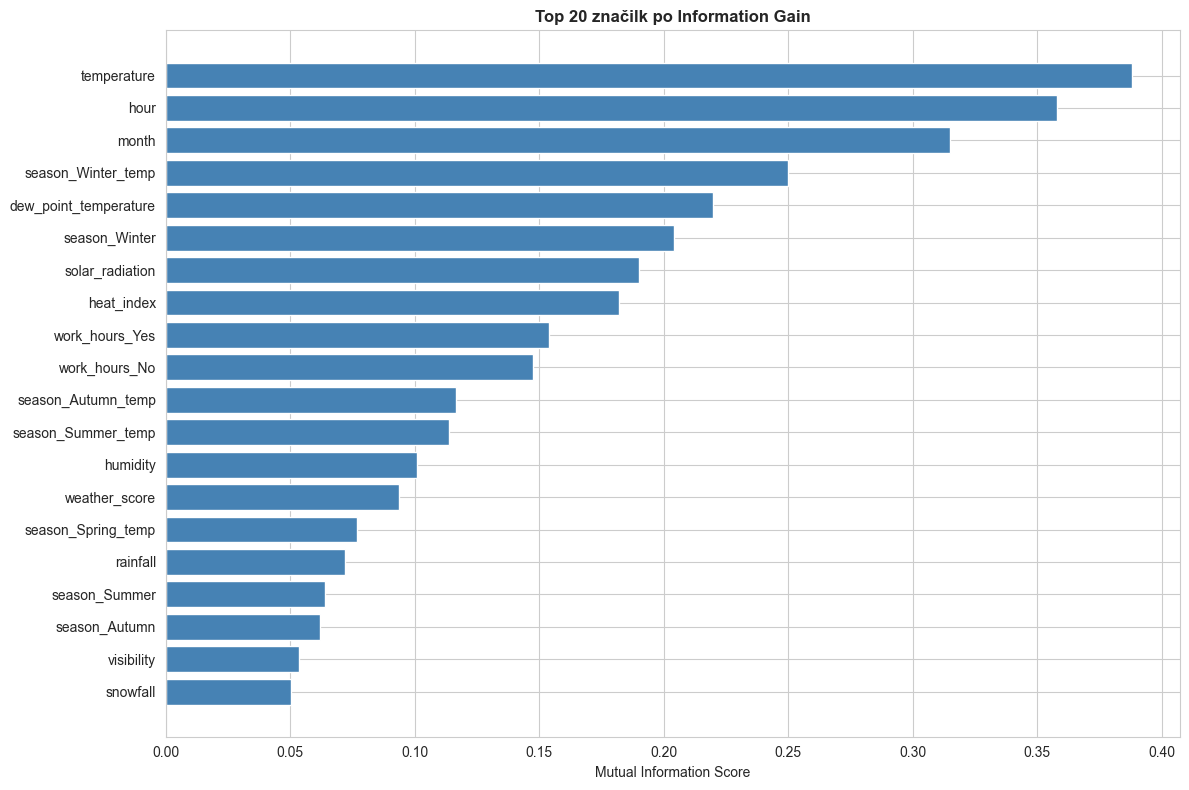


✅ Izbrano značilk: 20
Prag: MI Score > 0.05
Končna dimenzija: (8760, 20)


In [10]:
print("="*70)
print("IZBIRA ZNAČILK - Information Gain (Mutual Information)")
print("="*70)

# Priprava X in y
X_bike = df_bike_encoded.drop('rented_bike_count', axis=1)
y_bike = df_bike_encoded['rented_bike_count']

# Izračun mutual information
mi_scores = mutual_info_regression(X_bike, y_bike, random_state=1234)

# Ustvari DataFrame za prikaz
mi_df = pd.DataFrame({
    'Feature': X_bike.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("\n📊 TOP 20 značilk po Information Gain:")
print(mi_df.head(20).to_string(index=False))

# Vizualizacija
plt.figure(figsize=(12, 8))
plt.barh(mi_df.head(20)['Feature'], mi_df.head(20)['MI_Score'], color='steelblue')
plt.xlabel('Mutual Information Score')
plt.title('Top 20 značilk po Information Gain', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Izberemo značilke (npr. tiste z MI > 0.05 ali top N)
threshold = 0.05  # Ali uporabite: top_n = 15
selected_features = mi_df[mi_df['MI_Score'] > threshold]['Feature'].tolist()

print(f"\n✅ Izbrano značilk: {len(selected_features)}")
print(f"Prag: MI Score > {threshold}")

# Ustvarimo končni X
X_bike_selected = X_bike[selected_features]
print(f"Končna dimenzija: {X_bike_selected.shape}")


In [11]:
print("="*70)
print("STANDARDIZACIJA PODATKOV")
print("="*70)

# StandardScaler za značilke
scaler_reg = StandardScaler()
X_bike_scaled = pd.DataFrame(
    scaler_reg.fit_transform(X_bike_selected),
    columns=X_bike_selected.columns
)

print("✅ Podatki standardizirani (mean=0, std=1)")
print(f"\nOblika: {X_bike_scaled.shape}")
print(f"\nPrimer standardiziranih vrednosti:")
print(X_bike_scaled.head())


STANDARDIZACIJA PODATKOV
✅ Podatki standardizirani (mean=0, std=1)

Oblika: (8760, 20)

Primer standardiziranih vrednosti:
   temperature      hour     month  season_Winter_temp  dew_point_temperature  \
0    -1.513957 -1.661325  1.587648           -1.562062              -1.556915   
1    -1.539074 -1.516862  1.587648           -1.664523              -1.556915   
2    -1.580936 -1.372399  1.587648           -1.835293              -1.563130   
3    -1.597680 -1.227936  1.587648           -1.903601              -1.556915   
4    -1.580936 -1.083473  1.587648           -1.835293              -1.618983   

   season_Winter  solar_radiation  heat_index  work_hours_Yes  work_hours_No  \
0       1.748015        -0.845761   -1.699610         0.18668       -0.18668   
1       1.748015        -0.845761   -1.687764         0.18668       -0.18668   
2       1.748015        -0.845761   -1.687764         0.18668       -0.18668   
3       1.748015        -0.845761   -1.669996         0.18668       -0

NALAGANJE PODATKOV - KLASIFIKACIJA (Shapes Dataset)

📂 Nalaganje: circles (label=0)

📂 Nalaganje: squares (label=1)

📂 Nalaganje: triangles (label=2)

✅ Naloženih slik: 300
Oblika slike: (64, 64)

Porazdelitev razredov:
  circles: 100 slik
  squares: 100 slik
  triangles: 100 slik


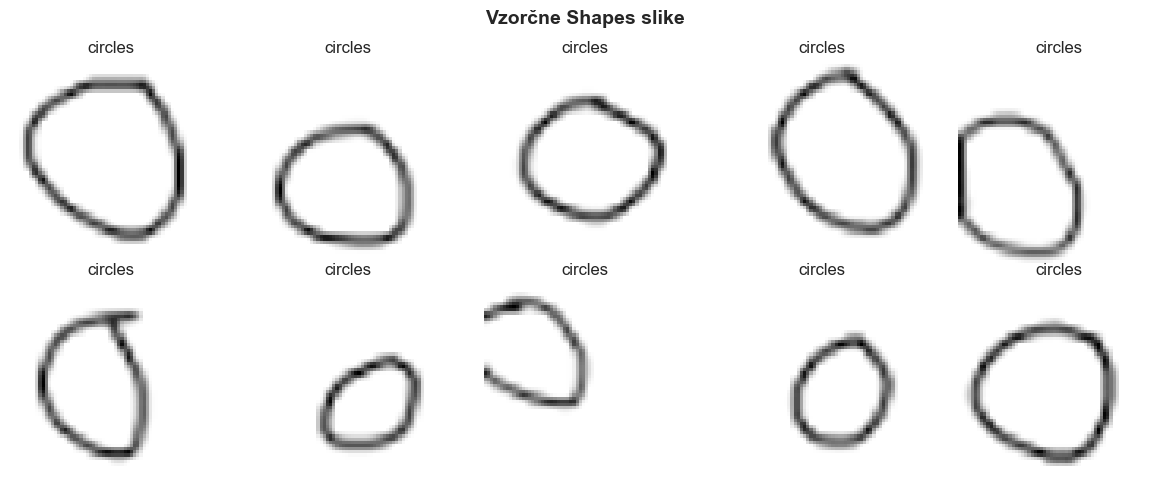

In [25]:
print("="*70)
print("NALAGANJE PODATKOV - KLASIFIKACIJA (Shapes Dataset)")
print("="*70)

import os
from PIL import Image

# Pot do shapes direktorija
shapes_path = 'shapes/'  # Prilagodite pot

# Kategorije
categories = ['circles', 'squares', 'triangles']

# Nalaganje slik
X_shapes = []
y_shapes = []

for label, category in enumerate(categories):
    category_path = os.path.join(shapes_path, category)

    if os.path.exists(category_path):
        print(f"\n📂 Nalaganje: {category} (label={label})")

        for img_name in os.listdir(category_path):
            if img_name.endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(category_path, img_name)

                try:
                    img = Image.open(img_path).convert('L')  # Grayscale
                    img = img.resize((64, 64))  # Resize
                    img_array = np.array(img)

                    X_shapes.append(img_array)
                    y_shapes.append(label)

                except Exception as e:
                    print(f"  ⚠️ Napaka: {img_name}")

X_shapes = np.array(X_shapes)
y_shapes = np.array(y_shapes)

print(f"\n✅ Naloženih slik: {len(X_shapes)}")
print(f"Oblika slike: {X_shapes[0].shape}")
print(f"\nPorazdelitev razredov:")
for i, cat in enumerate(categories):
    count = (y_shapes == i).sum()
    print(f"  {cat}: {count} slik")

# Vizualizacija
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Vzorčne Shapes slike', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(X_shapes):
        ax.imshow(X_shapes[i], cmap='gray')
        ax.set_title(f'{categories[y_shapes[i]]}')
        ax.axis('off')

plt.tight_layout()
plt.show()


In [26]:
print("="*70)
print("OBVEZNI DEL - Normalizacija slik (Shapes)")
print("="*70)

# Normalizacija (0-1 range)
X_shapes_normalized = X_shapes.astype('float32') / 255.0

# Flatten
X_shapes_flat = X_shapes_normalized.reshape(len(X_shapes_normalized), -1)

print(f"✅ Slike normalizirane (0-1)")
print(f"Oblika po flatten: {X_shapes_flat.shape}")

# DataFrame za CV
X_shapes_df = pd.DataFrame(X_shapes_flat)
y_shapes_df = pd.Series(y_shapes)

print(f"Min: {X_shapes_flat.min():.4f}, Max: {X_shapes_flat.max():.4f}")


OBVEZNI DEL - Normalizacija slik (Shapes)
✅ Slike normalizirane (0-1)
Oblika po flatten: (300, 4096)
Min: 0.0157, Max: 1.0000


In [27]:
def manual_cross_validation(X, y, models_dict, problem_type='regression', n_splits=5):
    """
    Ročna 5-fold cross-validacija
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=1234)
    results = []

    for model_name, model in models_dict.items():
        print(f"\n Treniranje modela: {model_name}")
        fold_num = 1

        for train_idx, test_idx in kf.split(X):
            print(f"  Fold {fold_num}/{n_splits}", end="")

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            if problem_type == 'regression':
                mae = mean_absolute_error(y_test, y_pred)
                mse = mean_squared_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)

                mask = y_test != 0
                mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100 if mask.sum() > 0 else 0

                results.append({
                    'model': model_name,
                    'fold': fold_num,
                    'MAE': mae,
                    'MAPE': mape,
                    'MSE': mse,
                    'R2': r2
                })
                print(f" - MAE: {mae:.2f}, R2: {r2:.4f}")

            else:  # classification
                acc = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred, average='weighted')
                prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
                rec = recall_score(y_test, y_pred, average='weighted')

                results.append({
                    'model': model_name,
                    'fold': fold_num,
                    'Accuracy': acc,
                    'F1': f1,
                    'Precision': prec,
                    'Recall': rec
                })
                print(f" - Accuracy: {acc:.4f}, F1: {f1:.4f}")

            fold_num += 1

    return pd.DataFrame(results)

print("✅ Funkcija manual_cross_validation definirana!")


✅ Funkcija manual_cross_validation definirana!


In [29]:
print("="*70)
print("DEFINICIJA MODELOV")
print("="*70)

# REGRESIJSKI MODELI
regression_models = {
    'Bagging': BaggingRegressor(n_estimators=50, random_state=1234),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=1234),
    'AdaBoost': AdaBoostRegressor(n_estimators=50, random_state=1234),
    'XGBoost': XGBRegressor(n_estimators=50, random_state=1234, verbosity=0),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(100,), max_iter=500,
                                   random_state=1234, early_stopping=True)
}

# KLASIFIKACIJSKI MODELI (za 3 razrede: circles, squares, triangles)
classification_models = {
    'Bagging': BaggingClassifier(n_estimators=50, random_state=1234),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=1234),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=1234),
    'XGBoost': XGBClassifier(n_estimators=50, random_state=1234,
                             eval_metric='mlogloss', use_label_encoder=False, verbosity=0),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100,), max_iter=500,
                                    random_state=1234, early_stopping=True)
}

print("✅ Modeli definirani:")
print(f"  Regresijski: {list(regression_models.keys())}")
print(f"  Klasifikacijski: {list(classification_models.keys())}")
print(f"  Klasifikacija - razredi: {categories}")


DEFINICIJA MODELOV
✅ Modeli definirani:
  Regresijski: ['Bagging', 'Random Forest', 'AdaBoost', 'XGBoost', 'Neural Network']
  Klasifikacijski: ['Bagging', 'Random Forest', 'AdaBoost', 'XGBoost', 'Neural Network']
  Klasifikacija - razredi: ['circles', 'squares', 'triangles']


In [30]:
print("="*70)
print("5-FOLD CV - REGRESIJA (Obvezni del)")
print("="*70)

results_reg_basic = manual_cross_validation(
    X_bike_scaled,
    y_bike,
    regression_models,
    problem_type='regression',
    n_splits=5
)

# Povprečja
avg_reg_basic = results_reg_basic.groupby('model').mean().drop('fold', axis=1)
print("\n POVPREČNI REZULTATI:")
print(avg_reg_basic.round(4))


5-FOLD CV - REGRESIJA (Obvezni del)

 Treniranje modela: Bagging
  Fold 1/5 - MAE: 139.51, R2: 0.8836
  Fold 2/5 - MAE: 134.20, R2: 0.8840
  Fold 3/5 - MAE: 138.22, R2: 0.8665
  Fold 4/5 - MAE: 148.55, R2: 0.8513
  Fold 5/5 - MAE: 132.26, R2: 0.8888

 Treniranje modela: Random Forest
  Fold 1/5 - MAE: 138.93, R2: 0.8837
  Fold 2/5 - MAE: 133.45, R2: 0.8846
  Fold 3/5 - MAE: 139.05, R2: 0.8650
  Fold 4/5 - MAE: 147.76, R2: 0.8535
  Fold 5/5 - MAE: 132.24, R2: 0.8885

 Treniranje modela: AdaBoost
  Fold 1/5 - MAE: 375.26, R2: 0.5718
  Fold 2/5 - MAE: 350.95, R2: 0.6026
  Fold 3/5 - MAE: 352.51, R2: 0.5645
  Fold 4/5 - MAE: 338.66, R2: 0.5881
  Fold 5/5 - MAE: 368.61, R2: 0.5628

 Treniranje modela: XGBoost
  Fold 1/5 - MAE: 141.04, R2: 0.8873
  Fold 2/5 - MAE: 137.46, R2: 0.8846
  Fold 3/5 - MAE: 143.04, R2: 0.8656
  Fold 4/5 - MAE: 147.69, R2: 0.8596
  Fold 5/5 - MAE: 132.88, R2: 0.8870

 Treniranje modela: Neural Network
  Fold 1/5 - MAE: 231.05, R2: 0.7413
  Fold 2/5 - MAE: 220.19, R2

In [31]:
print("="*70)
print("5-FOLD CV - KLASIFIKACIJA (Obvezni del - Shapes)")
print("="*70)

results_class_basic = manual_cross_validation(
    X_shapes_df,
    y_shapes_df,
    classification_models,
    problem_type='classification',
    n_splits=5
)

# Izpis po foldih
print("\n" + "-"*70)
print("REZULTATI PO FOLDIH:")
print("-"*70)
print(results_class_basic.to_string(index=False))

# Povprečja
avg_class_basic = results_class_basic.groupby('model').mean().drop('fold', axis=1)
print("\n" + "="*70)
print("📊 POVPREČNI REZULTATI - KLASIFIKACIJA:")
print("="*70)
print(avg_class_basic.round(4))


5-FOLD CV - KLASIFIKACIJA (Obvezni del - Shapes)

 Treniranje modela: Bagging
  Fold 1/5 - Accuracy: 0.6000, F1: 0.6033
  Fold 2/5 - Accuracy: 0.5000, F1: 0.4999
  Fold 3/5 - Accuracy: 0.5000, F1: 0.5033
  Fold 4/5 - Accuracy: 0.4167, F1: 0.4170
  Fold 5/5 - Accuracy: 0.4333, F1: 0.4321

 Treniranje modela: Random Forest
  Fold 1/5 - Accuracy: 0.6167, F1: 0.6127
  Fold 2/5 - Accuracy: 0.5667, F1: 0.5671
  Fold 3/5 - Accuracy: 0.6000, F1: 0.6049
  Fold 4/5 - Accuracy: 0.5333, F1: 0.5201
  Fold 5/5 - Accuracy: 0.5167, F1: 0.5199

 Treniranje modela: AdaBoost
  Fold 1/5 - Accuracy: 0.5000, F1: 0.5027
  Fold 2/5 - Accuracy: 0.5000, F1: 0.4986
  Fold 3/5 - Accuracy: 0.4833, F1: 0.4867
  Fold 4/5 - Accuracy: 0.4500, F1: 0.4488
  Fold 5/5 - Accuracy: 0.4000, F1: 0.3935

 Treniranje modela: XGBoost
  Fold 1/5 - Accuracy: 0.5833, F1: 0.5802
  Fold 2/5 - Accuracy: 0.4833, F1: 0.4809
  Fold 3/5 - Accuracy: 0.5500, F1: 0.5502
  Fold 4/5 - Accuracy: 0.4500, F1: 0.4323
  Fold 5/5 - Accuracy: 0.5000,

VIZUALIZACIJE - KLASIFIKACIJA (Boxploti)


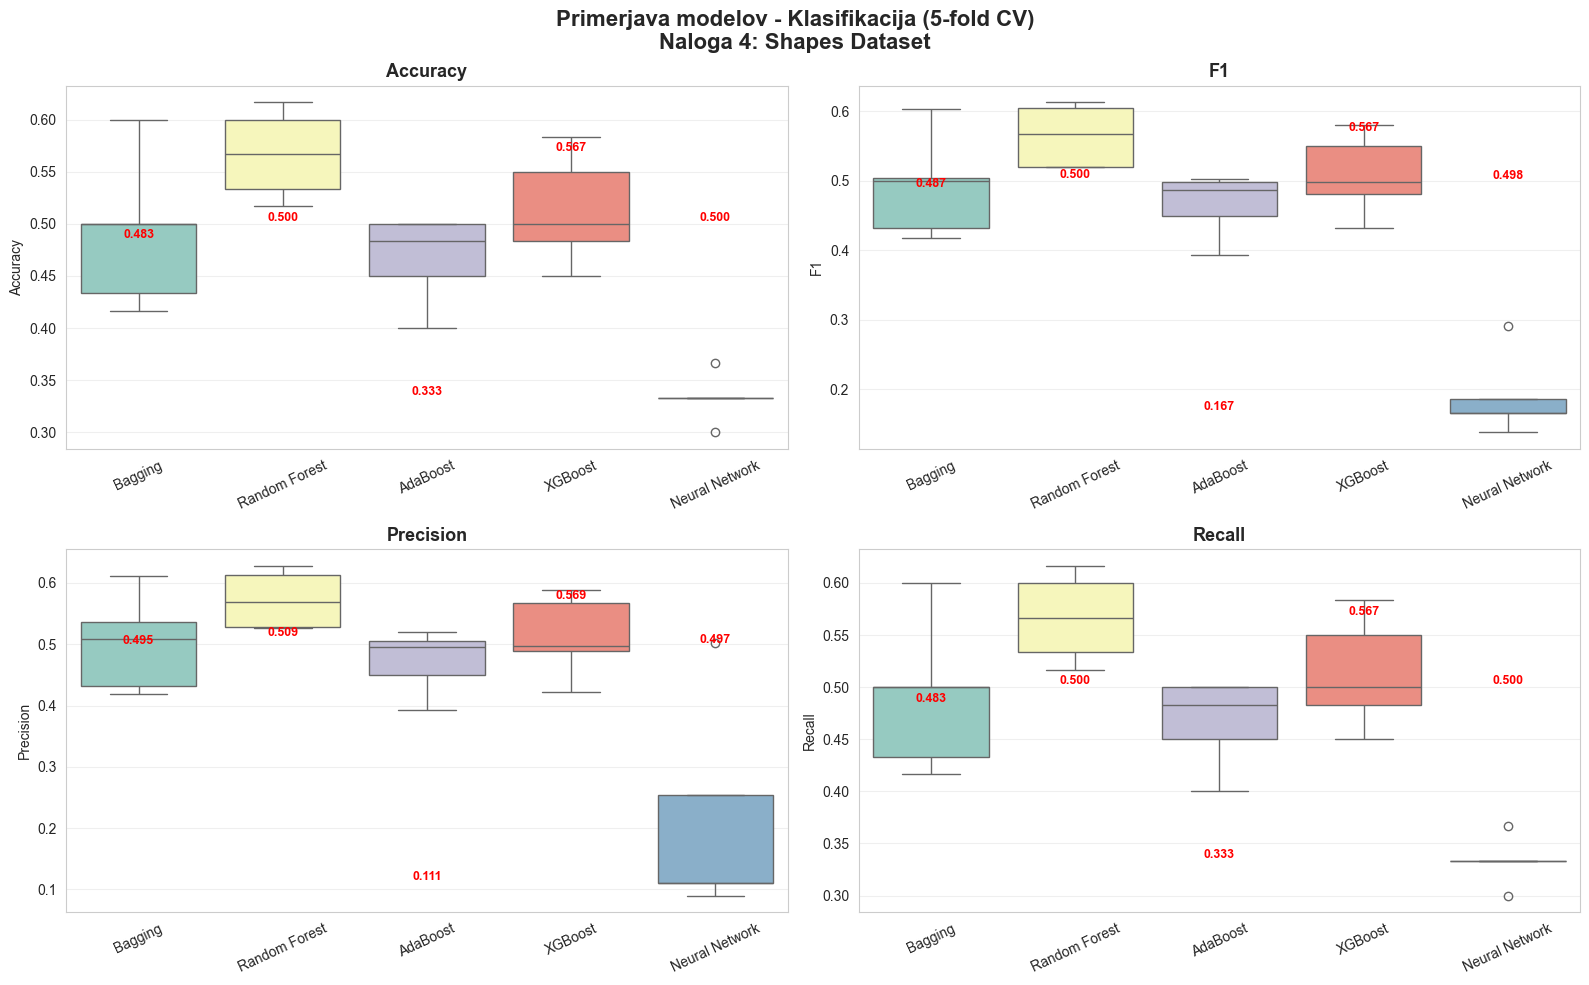

In [32]:
print("="*70)
print("VIZUALIZACIJE - KLASIFIKACIJA (Boxploti)")
print("="*70)

# Boxploti
metrics_class = ['Accuracy', 'F1', 'Precision', 'Recall']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Primerjava modelov - Klasifikacija (5-fold CV)\nNaloga 4: Shapes Dataset',
             fontsize=16, fontweight='bold')

for idx, metric in enumerate(metrics_class):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=results_class_basic, x='model', y=metric, ax=ax, palette='Set3')
    ax.set_title(f'{metric}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)

    # Mediana
    medians = results_class_basic.groupby('model')[metric].median()
    for i, model in enumerate(medians.index):
        ax.text(i, medians[model], f'{medians[model]:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('naloga4_klasifikacija_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()


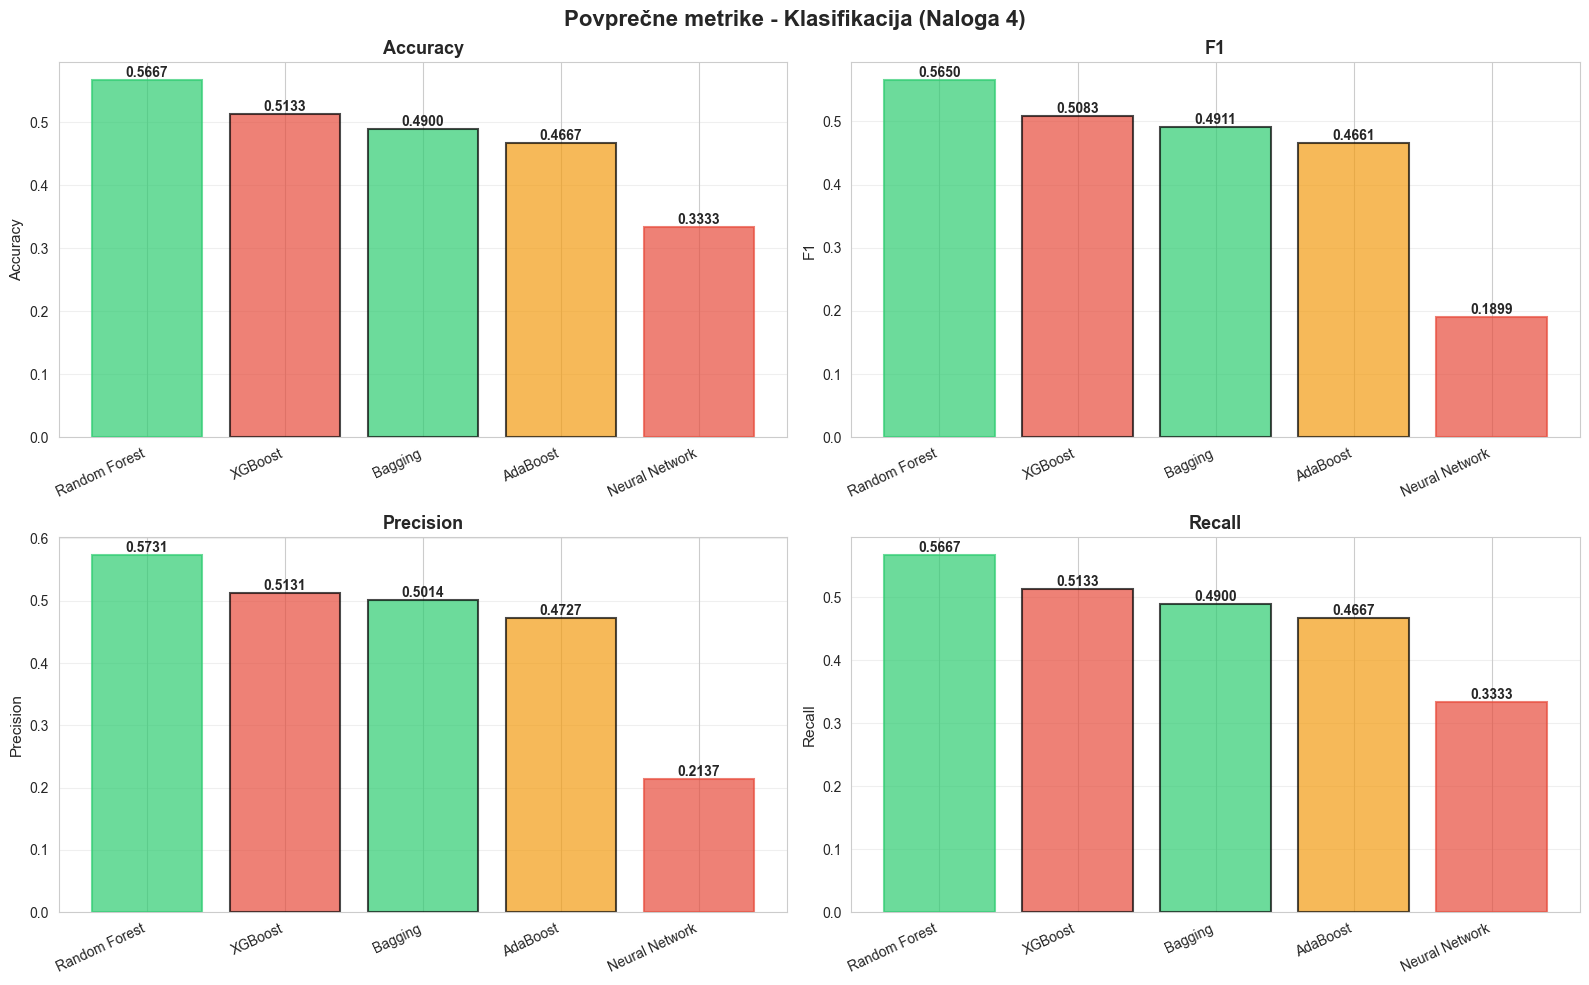

✅ Vizualizacije shranjene:
  📁 naloga4_klasifikacija_boxplots.png
  📁 naloga4_klasifikacija_povprecja.png


In [33]:
# Stolpični grafi
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Povprečne metrike - Klasifikacija (Naloga 4)', fontsize=16, fontweight='bold')

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, metric in enumerate(metrics_class):
    ax = axes[idx // 2, idx % 2]
    values = avg_class_basic[metric].sort_values(ascending=False)  # Višje je boljše

    bars = ax.bar(range(len(values)), values.values, color=colors, alpha=0.7,
                  edgecolor='black', linewidth=1.5)

    ax.set_title(f'{metric}', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(values.index, rotation=25, ha='right')
    ax.grid(axis='y', alpha=0.3)

    # Vrednosti na stolpcih
    for bar, val in zip(bars, values.values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Označi najboljšega in najslabšega
    bars[0].set_color('#2ecc71')  # Najboljši = zeleno
    bars[-1].set_color('#e74c3c')  # Najslabši = rdeče

plt.tight_layout()
plt.savefig('naloga4_klasifikacija_povprecja.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Vizualizacije shranjene:")
print("  📁 naloga4_klasifikacija_boxplots.png")
print("  📁 naloga4_klasifikacija_povprecja.png")


In [34]:
print("="*70)
print("RANKING MODELOV - KLASIFIKACIJA")
print("="*70)

# Ranking
ranking_data_class = []

for metric in metrics_class:
    sorted_models = avg_class_basic[metric].sort_values(ascending=False)  # Višje je boljše

    for rank, (model, value) in enumerate(sorted_models.items(), 1):
        ranking_data_class.append({
            'Metric': metric,
            'Rank': rank,
            'Model': model,
            'Value': value
        })

ranking_df_class = pd.DataFrame(ranking_data_class)

# Prikaz
print("\n📊 RANKING PO METRIKAH:\n")
for metric in metrics_class:
    print(f"\n{metric}:")
    metric_ranking = ranking_df_class[ranking_df_class['Metric'] == metric][['Rank', 'Model', 'Value']]
    print(metric_ranking.to_string(index=False))

# Skupni ranking
print("\n" + "="*70)
print("SKUPNI RANKING (povprečje rangov):")
print("="*70)

overall_ranking_class = ranking_df_class.groupby('Model')['Rank'].mean().sort_values()
print("\n🏆 NAJBOLJŠI → NAJSLABŠI:\n")
for rank, (model, avg_rank) in enumerate(overall_ranking_class.items(), 1):
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
    print(f"{medal} {rank}. {model:20s} (povprečni rang: {avg_rank:.2f})")


RANKING MODELOV - KLASIFIKACIJA

📊 RANKING PO METRIKAH:


Accuracy:
 Rank          Model    Value
    1  Random Forest 0.566667
    2        XGBoost 0.513333
    3        Bagging 0.490000
    4       AdaBoost 0.466667
    5 Neural Network 0.333333

F1:
 Rank          Model    Value
    1  Random Forest 0.564954
    2        XGBoost 0.508332
    3        Bagging 0.491138
    4       AdaBoost 0.466061
    5 Neural Network 0.189897

Precision:
 Rank          Model    Value
    1  Random Forest 0.573063
    2        XGBoost 0.513077
    3        Bagging 0.501364
    4       AdaBoost 0.472684
    5 Neural Network 0.213720

Recall:
 Rank          Model    Value
    1  Random Forest 0.566667
    2        XGBoost 0.513333
    3        Bagging 0.490000
    4       AdaBoost 0.466667
    5 Neural Network 0.333333

SKUPNI RANKING (povprečje rangov):

🏆 NAJBOLJŠI → NAJSLABŠI:

🥇 1. Random Forest        (povprečni rang: 1.00)
🥈 2. XGBoost              (povprečni rang: 2.00)
🥉 3. Bagging             

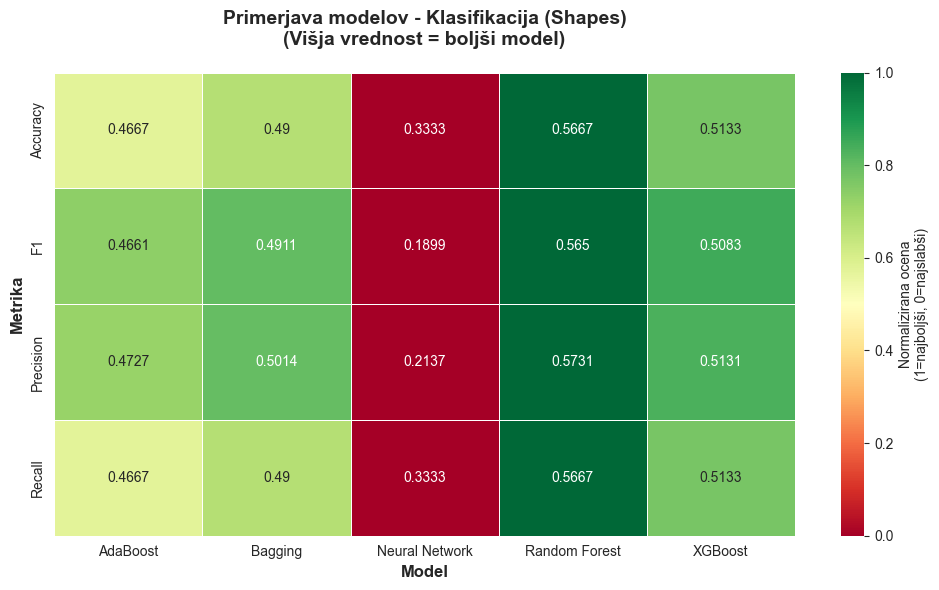

✅ Heatmap shranjen: naloga4_klasifikacija_heatmap.png


In [35]:
# Heatmap
fig, ax = plt.subplots(figsize=(10, 6))

# Normalizacija (višje je boljše za vse metrike)
normalized_data_class = avg_class_basic.copy()

for col in metrics_class:
    min_val = normalized_data_class[col].min()
    max_val = normalized_data_class[col].max()
    normalized_data_class[col] = (normalized_data_class[col] - min_val) / (max_val - min_val)

sns.heatmap(normalized_data_class.T, annot=avg_class_basic.T.round(4),
            fmt='', cmap='RdYlGn', cbar_kws={'label': 'Normalizirana ocena\n(1=najboljši, 0=najslabši)'},
            linewidths=0.5, ax=ax, vmin=0, vmax=1)

ax.set_title('Primerjava modelov - Klasifikacija (Shapes)\n(Višja vrednost = boljši model)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Metrika', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('naloga4_klasifikacija_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Heatmap shranjen: naloga4_klasifikacija_heatmap.png")


In [36]:
print("="*70)
print("KONČNA ANALIZA - OBVEZNI DEL")
print("="*70)

print("\n" + "="*70)
print("📊 REGRESIJA - Najboljši model:")
print("="*70)
best_reg_model = avg_reg_basic['R2'].idxmax()
print(f"🏆 {best_reg_model}")
print(f"   R² = {avg_reg_basic.loc[best_reg_model, 'R2']:.4f}")
print(f"   MAE = {avg_reg_basic.loc[best_reg_model, 'MAE']:.2f}")

print("\n" + "="*70)
print("📊 KLASIFIKACIJA - Najboljši model:")
print("="*70)
best_class_model = avg_class_basic['Accuracy'].idxmax()
print(f"🏆 {best_class_model}")
print(f"   Accuracy = {avg_class_basic.loc[best_class_model, 'Accuracy']:.4f}")
print(f"   F1 Score = {avg_class_basic.loc[best_class_model, 'F1']:.4f}")

print("\n" + "="*70)
print("SHRANJENE DATOTEKE:")
print("="*70)
print("📁 Regresija:")
print("  • naloga4_regresija_boxplots.png")
print("  • naloga4_regresija_povprecja.png")
print("  • naloga4_regresija_heatmap.png")
print("\n📁 Klasifikacija:")
print("  • naloga4_klasifikacija_boxplots.png")
print("  • naloga4_klasifikacija_povprecja.png")
print("  • naloga4_klasifikacija_heatmap.png")

print("\n✅ OBVEZNI DEL KONČAN!")


KONČNA ANALIZA - OBVEZNI DEL

📊 REGRESIJA - Najboljši model:
🏆 XGBoost
   R² = 0.8768
   MAE = 140.42

📊 KLASIFIKACIJA - Najboljši model:
🏆 Random Forest
   Accuracy = 0.5667
   F1 Score = 0.5650

SHRANJENE DATOTEKE:
📁 Regresija:
  • naloga4_regresija_boxplots.png
  • naloga4_regresija_povprecja.png
  • naloga4_regresija_heatmap.png

📁 Klasifikacija:
  • naloga4_klasifikacija_boxplots.png
  • naloga4_klasifikacija_povprecja.png
  • naloga4_klasifikacija_heatmap.png

✅ OBVEZNI DEL KONČAN!
